In [1]:
import ROOT

Welcome to JupyROOT 6.28/04


In [24]:
dropout_p_list = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
sigHists = {}
bkgHists = {}

# get signal histograms
for dropout_p in dropout_p_list:
    f = ROOT.TFile.Open(f"../outputs/ex5/ParticleNet_{str(dropout_p).replace('.', 'p')}.root")
    sigHist = f.Get(f"mask_sig_{str(dropout_p).replace('.', 'p')}"); sigHist.SetDirectory(0)
    bkgHist = f.Get(f"mask_bkg_{str(dropout_p).replace('.', 'p')}"); bkgHist.SetDirectory(0)
    sigHists[dropout_p] = sigHist
    bkgHists[dropout_p] = bkgHist

In [78]:
sigGraph = ROOT.TGraphErrors()
bkgGraph = ROOT.TGraphErrors()
for idx, (dropout_p, hist) in enumerate(sigHists.items()):
    sigGraph.SetPoint(idx, dropout_p, hist.GetMean())
    sigGraph.SetPointError(idx, 0., hist.GetStdDev())
    
for idx, (dropout_p, hist) in enumerate(bkgHists.items()):
    bkgGraph.SetPoint(idx, dropout_p, hist.GetMean())
    bkgGraph.SetPointError(idx, 0., hist.GetStdDev())

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


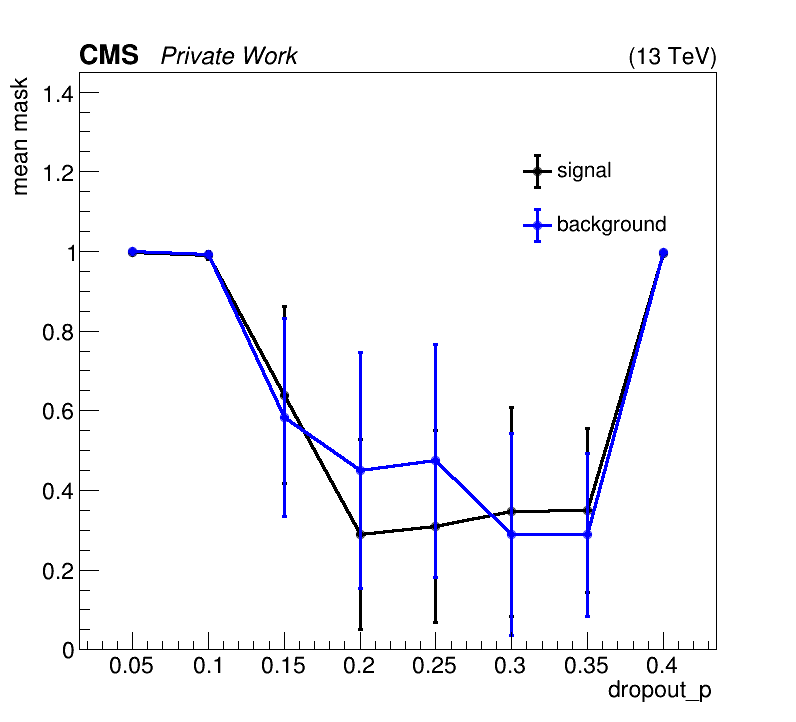

In [89]:
c = ROOT.TCanvas("canvas", "", 800, 750)
c.cd()

sigGraph.GetXaxis().SetTitle("dropout_p")
sigGraph.GetYaxis().SetTitle("mean mask")
sigGraph.GetYaxis().SetRangeUser(0., 1.45)
sigGraph.SetLineColor(ROOT.kBlack)
sigGraph.SetLineWidth(3)
sigGraph.SetMarkerColor(ROOT.kBlack)
sigGraph.SetMarkerStyle(20)
sigGraph.SetMarkerSize(1)
sigGraph.SetFillColor(6);
sigGraph.SetFillStyle(3005);

bkgGraph.GetXaxis().SetTitle("dropout_p")
bkgGraph.GetYaxis().SetTitle("mean mask")
bkgGraph.GetYaxis().SetRangeUser(0., 1.45)
bkgGraph.SetLineColor(ROOT.kBlue)
bkgGraph.SetLineWidth(3)
bkgGraph.SetMarkerColor(ROOT.kBlue)
bkgGraph.SetMarkerStyle(20)
bkgGraph.SetMarkerSize(1)
bkgGraph.SetFillColor(6);
bkgGraph.SetFillStyle(3005);

legend = ROOT.TLegend(0.65, 0.65, 0.85, 0.8)
legend.SetFillStyle(0)
legend.SetBorderSize(0)
legend.AddEntry(sigGraph, "signal", "ple")
legend.AddEntry(bkgGraph, "background", "ple")

text = ROOT.TLatex()
def setCOMText():
    text.SetTextSize(0.035)
    text.SetTextFont(42)
    
def setCMSText():
    text.SetTextSize(0.04)
    text.SetTextFont(61)
    
def setWIPText():
    text.SetTextSize(0.036)
    text.SetTextFont(52)
    
#graph.Draw("a3")
sigGraph.Draw()
bkgGraph.Draw("pl&same")
legend.Draw()
setCOMText(); text.DrawLatexNDC(0.79, 0.91, "(13 TeV)")
setCMSText(); text.DrawLatexNDC(0.1, 0.91, "CMS")
setWIPText(); text.DrawLatexNDC(0.2, 0.91, "Private Work")
c.RedrawAxis()
c.Draw()